# Fraud Detection Capstone Project
### Boston Institute of Analytics — Data Science & Artificial Intelligence

**Objective:** Study financial transactions and build a machine learning model to detect fraud.

**Dataset:** `Fraud_Analysis_Dataset.xlsx`

## 1. Business Problem

The aim is to classify transactions as **legitimate (`0`)** or **fraudulent (`1`)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Load dataset
df = pd.read_excel("Fraud_Analysis_Dataset.xlsx")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully.
Rows: 11,142
Columns: 10


In [2]:
# First look at the data
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1
2,1,TRANSFER,"2,806.00",C1420196421,"2,806.00",0.00,C972765878,0.00,0.00,1
3,1,CASH_OUT,"2,806.00",C2101527076,"2,806.00",0.00,C1007251739,"26,202.00",0.00,1
4,1,TRANSFER,"20,128.00",C137533655,"20,128.00",0.00,C1848415041,0.00,0.00,1


In [3]:
# Dataset structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [4]:
# Statistical summary of numerical columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
step,"11,142.00",8.72,16.07,1.00,2.00,6.00,7.00,95.00
amount,"11,142.00","213,191.49","760,065.01",2.39,"4,946.62","16,761.26","154,336.58","10,000,000.00"
oldbalanceOrg,"11,142.00","924,117.26","2,143,004.31",0.00,427.00,"28,169.50","304,085.48","19,900,000.00"
newbalanceOrig,"11,142.00","824,957.65","2,089,894.17",0.00,0.00,"4,420.60","111,412.64","13,000,000.00"
oldbalanceDest,"11,142.00","888,354.08","2,601,375.85",0.00,0.00,0.00,"271,155.47","33,000,000.00"
newbalanceDest,"11,142.00","1,103,211.48","2,982,447.12",0.00,0.00,0.00,"318,637.36","34,600,000.00"
isFraud,"11,142.00",0.10,0.30,0.00,0.00,0.00,0.00,1.00


In [5]:
# Missing-value check
missing = df.isnull().sum().sort_values(ascending=False)
missing


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [6]:
# Duplicate-row check
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


## 2. Target Variable

In [7]:
# Target distribution
target_counts = df["isFraud"].value_counts().sort_index()

print(target_counts)
print("\nPercentage distribution:")
print((df["isFraud"].value_counts(normalize=True).sort_index() * 100).round(2))


isFraud
0    10000
1     1142
Name: count, dtype: int64

Percentage distribution:
isFraud
0   89.75
1   10.25
Name: proportion, dtype: float64


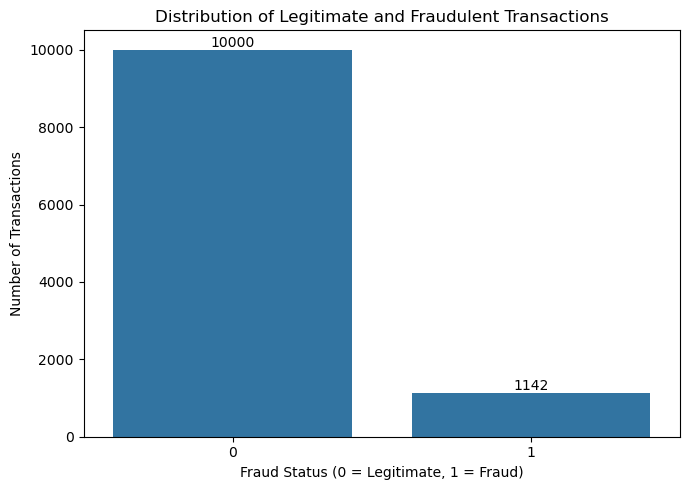

In [8]:
# Visualize target distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="isFraud")
plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


## 3. Transaction Types

The dataset has five transaction types:

- `CASH_IN`
- `CASH_OUT`
- `DEBIT`
- `PAYMENT`
- `TRANSFER`

In [9]:
# Transaction type vs fraud status
type_fraud = pd.crosstab(df["type"], df["isFraud"])
type_fraud


isFraud,0,1
type,,
CASH_IN,1951,0
CASH_OUT,1293,578
DEBIT,346,0
PAYMENT,5510,0
TRANSFER,900,564


In [10]:
# Fraud rate within each transaction type
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_type


type
TRANSFER   38.52
CASH_OUT   30.89
CASH_IN     0.00
DEBIT       0.00
PAYMENT     0.00
Name: isFraud, dtype: float64

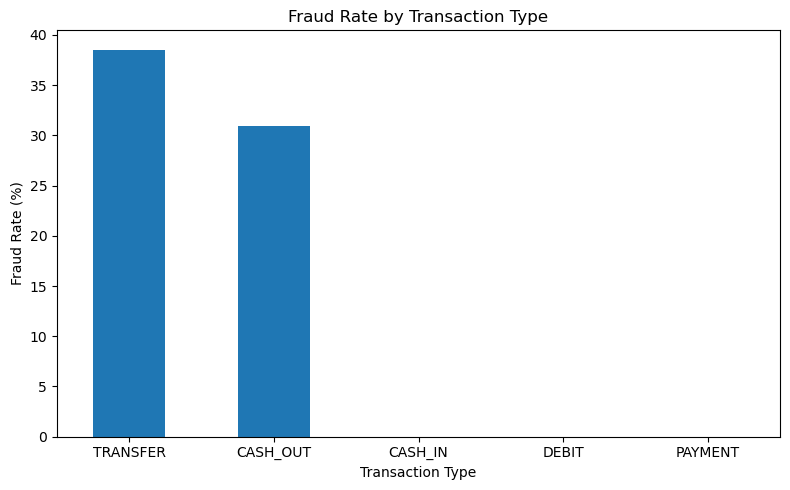

In [11]:
# Visualize fraud rate by transaction type
plt.figure(figsize=(8, 5))
fraud_rate_by_type.plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Transaction Amounts

In [12]:
# Compare amount statistics by fraud status
df.groupby("isFraud")["amount"].describe()


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"10,000.00","101,339.73","226,018.91",2.39,"4,373.51","12,725.24","113,909.36","3,776,389.09"
1,"1,142.00","1,192,628.93","2,030,598.96",119.00,"86,070.17","353,179.45","1,248,759.00","10,000,000.00"


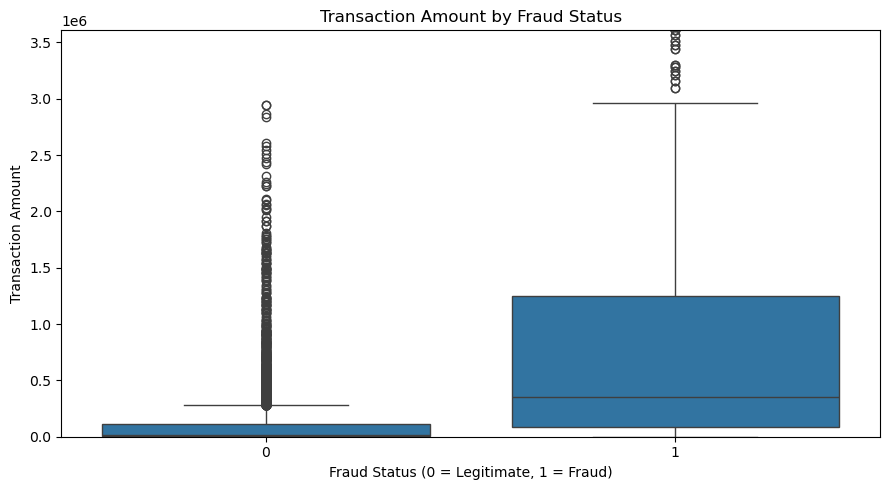

In [13]:
# Boxplot of transaction amounts by fraud status
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="isFraud", y="amount")
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.ylim(0, df["amount"].quantile(0.99))
plt.tight_layout()
plt.show()


## 5. Time Variable

The `step` column measures simulated time. One step equals one hour. We checked its distribution for legitimate and fraudulent transactions to see whether sampling or time differences could give the model clues about fraud.

In [14]:
# Fraud counts by simulated time step
step_fraud = pd.crosstab(df["step"], df["isFraud"])

print(step_fraud.head(15))
print("\nRange of step for each class:")
print(df.groupby("isFraud")["step"].agg(["min", "max", "mean", "median"]))


isFraud     0   1
step             
1        2692  16
2        1006   8
3         548   4
4         555  10
5         659   6
6        1638  22
7        2902  12
8           0  12
9           0  19
10          0  11
11          0   7
12          0  14
13          0  14
14          0  12
15          0  20

Range of step for each class:
         min  max  mean  median
isFraud                        
0          1    7  4.20    5.00
1          1   95 48.27   48.00


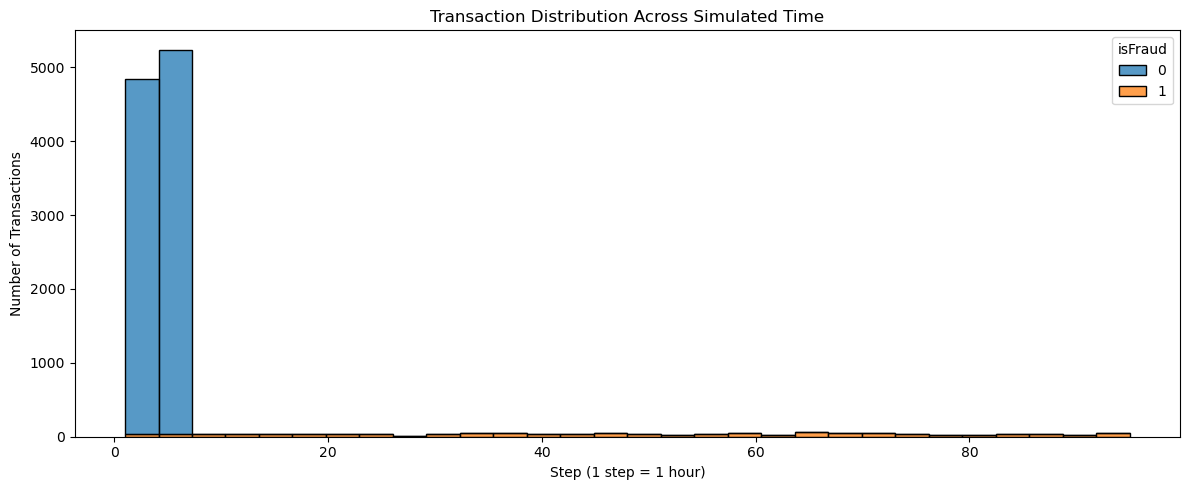

In [15]:
# Visualize the number of transactions by step and fraud status
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df,
    x="step",
    hue="isFraud",
    bins=30,
    multiple="stack"
)
plt.title("Transaction Distribution Across Simulated Time")
plt.xlabel("Step (1 step = 1 hour)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


## 6. Initial Findings

- 11,142 total transactions
- 10,000 legitimate transactions
- 1,142 fraudulent transactions
- Fraud rate: 10.25%

# 7. Feature Engineering

We created a few new features using the balance and transaction amount columns.

In [16]:
df["orig_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

df[[
    "oldbalanceOrg",
    "newbalanceOrig",
    "orig_balance_change",
    "isFraud"
]].head()

,oldbalanceOrg,newbalanceOrig,orig_balance_change,isFraud
0,181.00,0.00,181.00,1
1,181.00,0.00,181.00,1
2,"2,806.00",0.00,"2,806.00",1
3,"2,806.00",0.00,"2,806.00",1
4,"20,128.00",0.00,"20,128.00",1


In [17]:
df["dest_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]

df[[
    "oldbalanceDest",
    "newbalanceDest",
    "dest_balance_change",
    "isFraud"
]].head()

,oldbalanceDest,newbalanceDest,dest_balance_change,isFraud
0,0.00,0.00,0.00,1
1,"21,182.00",0.00,"-21,182.00",1
2,0.00,0.00,0.00,1
3,"26,202.00",0.00,"-26,202.00",1
4,0.00,0.00,0.00,1


In [18]:
df["orig_balance_error"] = df["amount"] - df["orig_balance_change"]

df[[
    "amount",
    "orig_balance_change",
    "orig_balance_error",
    "isFraud"
]].head()

,amount,orig_balance_change,orig_balance_error,isFraud
0,181.00,181.00,0.00,1
1,181.00,181.00,0.00,1
2,"2,806.00","2,806.00",0.00,1
3,"2,806.00","2,806.00",0.00,1
4,"20,128.00","20,128.00",0.00,1


In [19]:
df["dest_balance_error"] = df["amount"] - df["dest_balance_change"]

df[[
    "amount",
    "dest_balance_change",
    "dest_balance_error",
    "isFraud"
]].head()

,amount,dest_balance_change,dest_balance_error,isFraud
0,181.00,0.00,181.00,1
1,181.00,"-21,182.00","21,363.00",1
2,"2,806.00",0.00,"2,806.00",1
3,"2,806.00","-26,202.00","29,008.00",1
4,"20,128.00",0.00,"20,128.00",1


In [20]:
engineered_features = [
    "amount",
    "orig_balance_change",
    "dest_balance_change",
    "orig_balance_error",
    "dest_balance_error"
]

df.groupby("isFraud")[engineered_features].mean()

,amount,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error
isFraud,,,,,
0,"101,339.73","-24,808.18","168,010.62","126,147.91","-66,670.89"
1,"1,192,628.93","1,184,691.90","625,074.35","7,937.03","567,554.59"


In [21]:
df.groupby("isFraud")[engineered_features].median()

,amount,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error
isFraud,,,,,
0,"12,725.24",538.59,0.00,"5,573.72","6,605.92"
1,"353,179.45","348,705.15","3,733.04",0.00,"9,439.94"


In [22]:
fraud_df = df[df["isFraud"] == 1]

fraud_df[[
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change"
]].head(20)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_change,dest_balance_change
0,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,181.00,0.00
1,1,CASH_OUT,181.00,181.00,0.00,"21,182.00",0.00,181.00,"-21,182.00"
2,1,TRANSFER,"2,806.00","2,806.00",0.00,0.00,0.00,"2,806.00",0.00
3,1,CASH_OUT,"2,806.00","2,806.00",0.00,"26,202.00",0.00,"2,806.00","-26,202.00"
4,1,TRANSFER,"20,128.00","20,128.00",0.00,0.00,0.00,"20,128.00",0.00
5,1,CASH_OUT,"20,128.00","20,128.00",0.00,"6,268.00","12,145.85","20,128.00","5,877.85"
6,1,CASH_OUT,"416,001.33",0.00,0.00,102.00,"9,291,619.62",0.00,"9,291,517.62"
7,1,TRANSFER,"1,277,212.77","1,277,212.77",0.00,0.00,0.00,"1,277,212.77",0.00
8,1,CASH_OUT,"1,277,212.77","1,277,212.77",0.00,0.00,"2,444,985.19","1,277,212.77","2,444,985.19"
9,1,TRANSFER,"35,063.63","35,063.63",0.00,0.00,0.00,"35,063.63",0.00


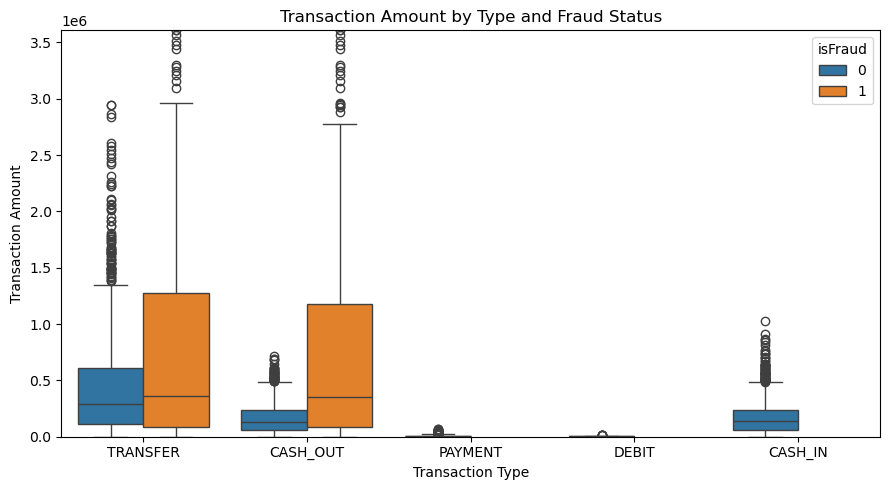

In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="type",
    y="amount",
    hue="isFraud"
)

plt.title("Transaction Amount by Type and Fraud Status")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.ylim(0, df["amount"].quantile(0.99))

plt.tight_layout()
plt.show()

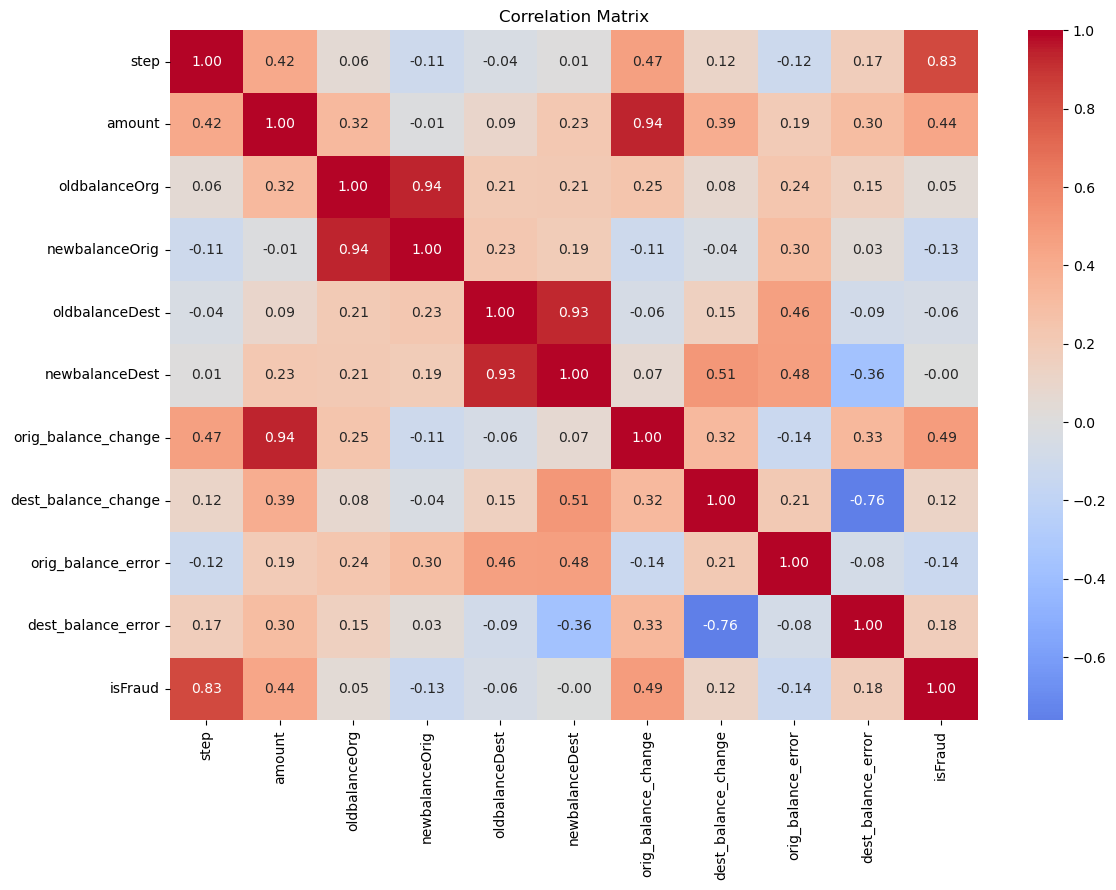

In [24]:
numeric_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change",
    "orig_balance_error",
    "dest_balance_error",
    "isFraud"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 8. Fraud by Transaction Type

We checked fraud counts for each transaction type. We also compared their fraud rates.

In [25]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

fraud_by_type

isFraud,0,1
type,,
CASH_IN,1951,0
CASH_OUT,1293,578
DEBIT,346,0
PAYMENT,5510,0
TRANSFER,900,564


In [26]:
fraud_by_type.columns = ["Legitimate", "Fraud"]

fraud_by_type

,Legitimate,Fraud
type,,
CASH_IN,1951,0
CASH_OUT,1293,578
DEBIT,346,0
PAYMENT,5510,0
TRANSFER,900,564


In [27]:
fraud_rate = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

fraud_rate

type
TRANSFER   0.39
CASH_OUT   0.31
CASH_IN    0.00
DEBIT      0.00
PAYMENT    0.00
Name: isFraud, dtype: float64

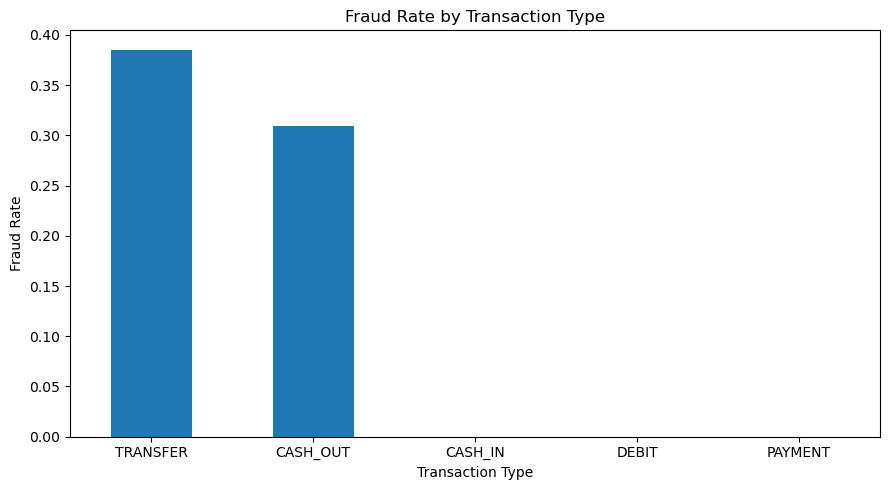

In [28]:
plt.figure(figsize=(9, 5))

fraud_rate.plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# Select features for machine learning
features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change",
    "orig_balance_error",
    "dest_balance_error",
    "type"
]

X = df[features].copy()
y = df["isFraud"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11142, 11)
Target shape: (11142,)


In [30]:
X = pd.get_dummies(
    X,
    columns=["type"],
    drop_first=True
)

X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,181.00,181.00,0.00,0.00,0.00,181.00,0.00,0.00,181.00,False,False,False,True
1,1,181.00,181.00,0.00,"21,182.00",0.00,181.00,"-21,182.00",0.00,"21,363.00",True,False,False,False
2,1,"2,806.00","2,806.00",0.00,0.00,0.00,"2,806.00",0.00,0.00,"2,806.00",False,False,False,True
3,1,"2,806.00","2,806.00",0.00,"26,202.00",0.00,"2,806.00","-26,202.00",0.00,"29,008.00",True,False,False,False
4,1,"20,128.00","20,128.00",0.00,0.00,0.00,"20,128.00",0.00,0.00,"20,128.00",False,False,False,True


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8913
Testing samples: 2229


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Results")
print("-" * 40)

print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
----------------------------------------
Precision: 1.0
Recall: 0.8991228070175439
F1 Score: 0.9468822170900693
ROC-AUC: 0.9911535460340006

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       1.00      0.90      0.95       228

    accuracy                           0.99      2229
   macro avg       0.99      0.95      0.97      2229
weighted avg       0.99      0.99      0.99      2229



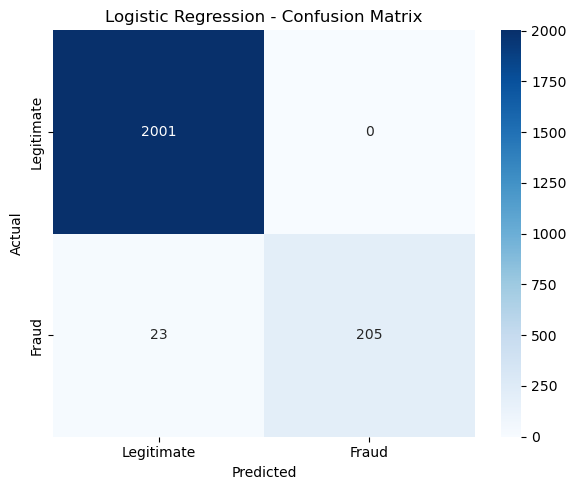

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results")
print("-" * 40)

print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
----------------------------------------
Precision: 1.0
Recall: 0.9956140350877193
F1 Score: 0.9978021978021978
ROC-AUC: 0.9999572582129987

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       228

    accuracy                           1.00      2229
   macro avg       1.00      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229



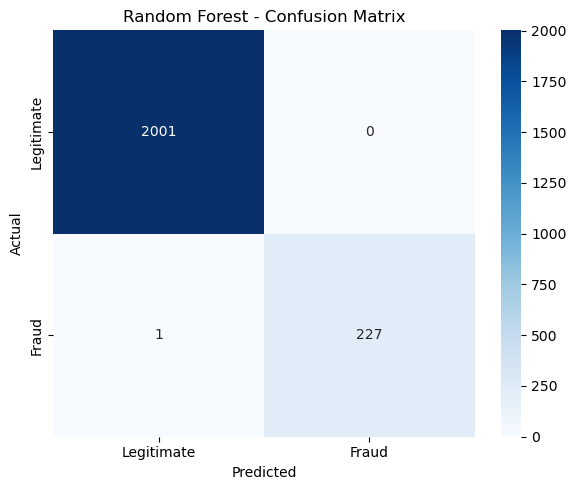

In [35]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Results")
print("-" * 45)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1 Score:", f1_gb)
print("ROC-AUC:", roc_auc_gb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
---------------------------------------------
Precision: 1.0
Recall: 0.9956140350877193
F1 Score: 0.9978021978021978
ROC-AUC: 0.999677792682606

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       228

    accuracy                           1.00      2229
   macro avg       1.00      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229



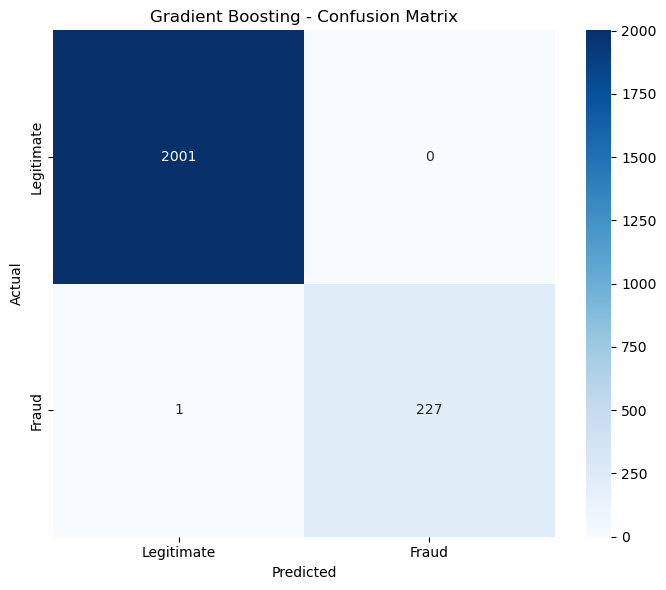

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [38]:
# Final Model Comparison - Exact Values

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_gb
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_gb
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_gb
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_gb
    ]
})

# Display exact values without np.float64
model_comparison.style.format({
    "Precision": "{:.15f}",
    "Recall": "{:.15f}",
    "F1 Score": "{:.15f}",
    "ROC-AUC": "{:.15f}"
})

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.000000000000000,0.899122807017544,0.946882217090069,0.991153546034001
1,Random Forest,1.000000000000000,0.995614035087719,0.997802197802198,0.999957258212999
2,Gradient Boosting,1.000000000000000,0.995614035087719,0.997802197802198,0.999677792682606


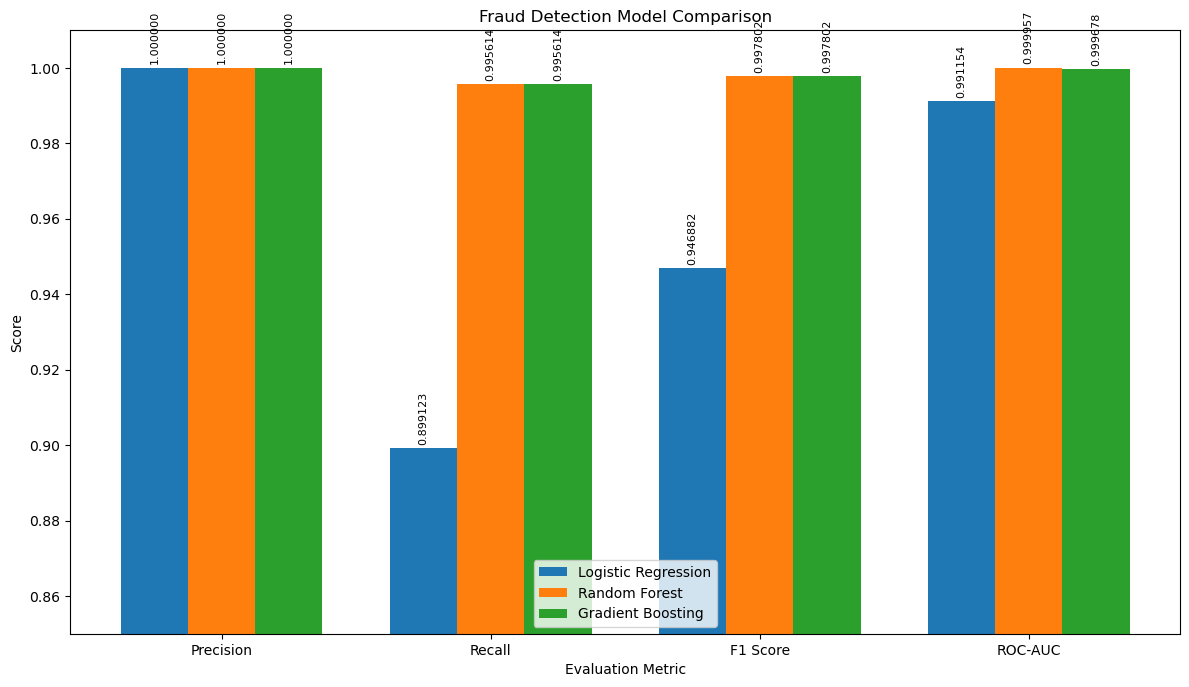

In [39]:
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC"]
models = model_comparison["Model"].tolist()

plt.figure(figsize=(12, 7))

x = range(len(metrics))
width = 0.25

for i, model in enumerate(models):
    values = model_comparison.iloc[i][metrics].astype(float).tolist()

    bars = plt.bar(
        [j + (i - 1) * width for j in x],
        values,
        width=width,
        label=model
    )

    # Display exact values
    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.001,
            f"{value:.6f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

plt.xticks(x, metrics)
plt.ylim(0.85, 1.01)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Fraud Detection Model Comparison")
plt.legend()

plt.tight_layout()
plt.show()

# 9. Feature Importance

We checked which features were most important for fraud detection.

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

feature_importance.style.format({
    "Importance": "{:.15f}"
})

,Feature,Importance
0,step,0.445970908064859
6,orig_balance_change,0.141126442410986
8,orig_balance_error,0.123547102931907
3,newbalanceOrig,0.070307242000189
1,amount,0.065764058036085
13,type_TRANSFER,0.030432061446091
5,newbalanceDest,0.022624425967215
4,oldbalanceDest,0.020765963356331
12,type_PAYMENT,0.018977798672023
10,type_CASH_OUT,0.016189962584904


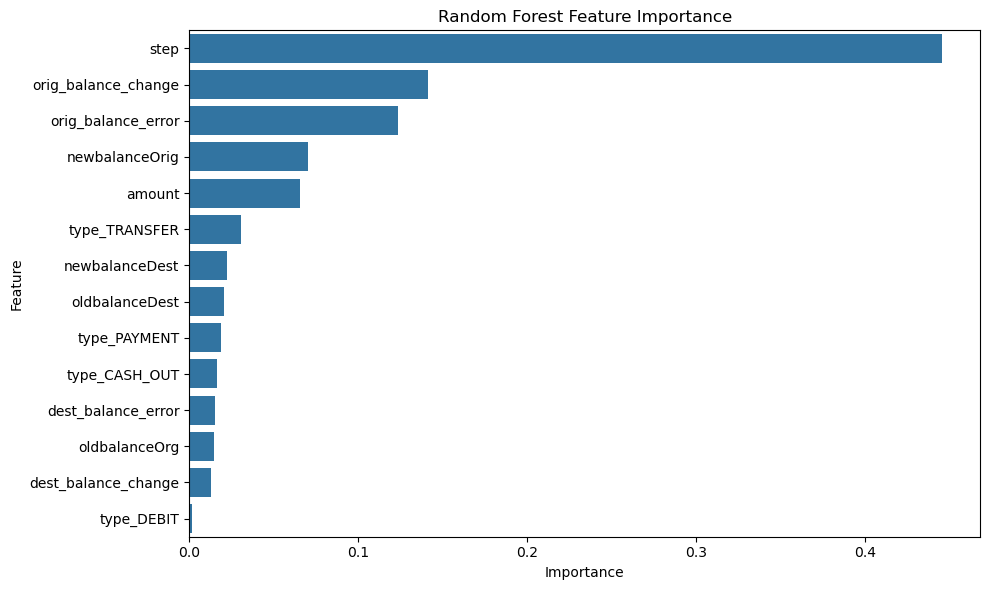

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [42]:
# Gradient Boosting Feature Importance

gb_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

gb_feature_importance = gb_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

gb_feature_importance

,Feature,Importance
0,step,0.93
3,newbalanceOrig,0.05
6,orig_balance_change,0.01
5,newbalanceDest,0.00
4,oldbalanceDest,0.00
2,oldbalanceOrg,0.00
8,orig_balance_error,0.00
1,amount,0.00
9,dest_balance_error,0.00
13,type_TRANSFER,0.00


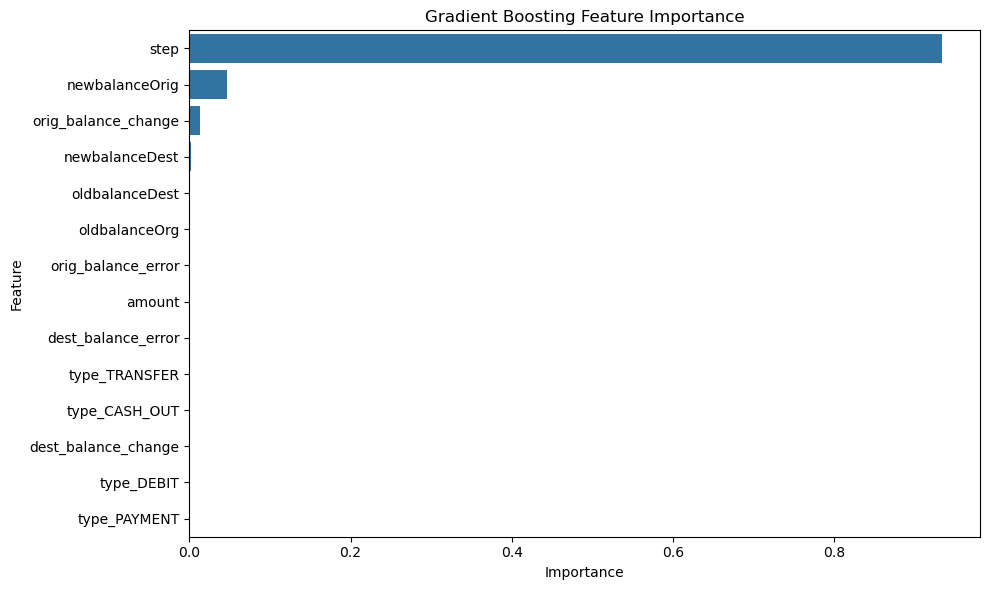

In [43]:
# Gradient Boosting Feature Importance Chart

plt.figure(figsize=(10, 6))

sns.barplot(
    data=gb_feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [44]:
# Final model comparison - retain numeric values for calculations and plots

final_comparison = model_comparison.copy()

final_comparison.style.format({
    "Precision": "{:.15f}",
    "Recall": "{:.15f}",
    "F1 Score": "{:.15f}",
    "ROC-AUC": "{:.15f}"
})

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.000000000000000,0.899122807017544,0.946882217090069,0.991153546034001
1,Random Forest,1.000000000000000,0.995614035087719,0.997802197802198,0.999957258212999
2,Gradient Boosting,1.000000000000000,0.995614035087719,0.997802197802198,0.999677792682606


In [45]:
# Financial Impact Analysis

fraud_transactions = df[df["isFraud"] == 1]

total_fraud_transactions = len(fraud_transactions)
total_fraud_loss = fraud_transactions["amount"].sum()

print("Total fraudulent transactions:", total_fraud_transactions)
print("Total fraud loss: ₹", total_fraud_loss)

Total fraudulent transactions: 1142
Total fraud loss: ₹ 1361982240.43


In [46]:
# Financial impact of missed fraud

rf_false_negative = (y_test == 1) & (y_pred_rf == 0)

missed_fraud_loss = df.loc[y_test.index[rf_false_negative], "amount"].sum()

print("Missed fraudulent transactions:", rf_false_negative.sum())
print("Potential loss from missed fraud: ₹", missed_fraud_loss)

Missed fraudulent transactions: 1
Potential loss from missed fraud: ₹ 416001.33


In [47]:
# Financial impact of false positives

rf_false_positive = (y_test == 0) & (y_pred_rf == 1)

false_positive_amount = df.loc[
    y_test.index[rf_false_positive],
    "amount"
].sum()

print("False positive transactions:", rf_false_positive.sum())
print("Amount involved in false positives: ₹", false_positive_amount)

False positive transactions: 0
Amount involved in false positives: ₹ 0.0


In [48]:
financial_impact = pd.DataFrame({
    "Metric": [
        "Total Fraud Transactions",
        "Total Fraud Amount",
        "Missed Fraud Transactions",
        "Potential Missed Fraud Loss",
        "False Positive Transactions",
        "False Positive Amount"
    ],
    "Value": [
        total_fraud_transactions,
        total_fraud_loss,
        rf_false_negative.sum(),
        missed_fraud_loss,
        rf_false_positive.sum(),
        false_positive_amount
    ]
})

financial_impact

,Metric,Value
0,Total Fraud Transactions,"1,142.00"
1,Total Fraud Amount,"1,361,982,240.43"
2,Missed Fraud Transactions,1.00
3,Potential Missed Fraud Loss,"416,001.33"
4,False Positive Transactions,0.00
5,False Positive Amount,0.00


In [49]:
# Clean Financial Impact Summary

financial_impact_display = financial_impact.copy()

financial_impact_display["Value"] = [
    f"{financial_impact.loc[0, 'Value']:,.0f}",
    f"₹{financial_impact.loc[1, 'Value']:,.2f}",
    f"{financial_impact.loc[2, 'Value']:,.0f}",
    f"₹{financial_impact.loc[3, 'Value']:,.2f}",
    f"{financial_impact.loc[4, 'Value']:,.0f}",
    f"₹{financial_impact.loc[5, 'Value']:,.2f}"
]

financial_impact_display

,Metric,Value
0,Total Fraud Transactions,"1,142"
1,Total Fraud Amount,"₹1,361,982,240.43"
2,Missed Fraud Transactions,1
3,Potential Missed Fraud Loss,"₹416,001.33"
4,False Positive Transactions,0
5,False Positive Amount,₹0.00


In [50]:
# Business Question 1: Model Performance

best_model = model_comparison.loc[
    model_comparison["Model"] == "Random Forest"
].iloc[0]

print("Business Question 1: Model Performance")
print("---------------------------------------")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")
print(f"F1 Score: {best_model['F1 Score']:.4f}")
print(f"ROC-AUC: {best_model['ROC-AUC']:.4f}")

Business Question 1: Model Performance
---------------------------------------
Precision: 1.0000
Recall: 0.9956
F1 Score: 0.9978
ROC-AUC: 1.0000


## Business Question 1: Model Performance

Random Forest had a precision of **1.0000**. All transactions it flagged as fraud were fraudulent in the test set.

Its recall was **0.9956**, so it detected about **99.56%** of fraudulent transactions. Test accuracy was about **99.96%**.

The **F1 Score of 0.9978** shows that both precision and recall were high. The **ROC-AUC of 1.0000** shows that the model distinguished legitimate and fraudulent transactions very well in this test set.

## Business Question 2: Classification Reliability

Random Forest had a precision of **1.0000**, recall of **0.9956**, and F1 Score of **0.9978** on the test set.

Of **228 fraudulent transactions**, it correctly identified **227** and missed **1**. There were **0 false positives**, so no legitimate transactions were flagged as fraud.

## Business Question 3: Financial Impact

Random Forest missed **1 fraudulent transaction**, with a potential loss of about **₹416,001.33**.

There were **0 false-positive transactions**, so the amount linked to false positives was **₹0.00** in the test set.

Even one missed fraud case can lead to a large potential loss.

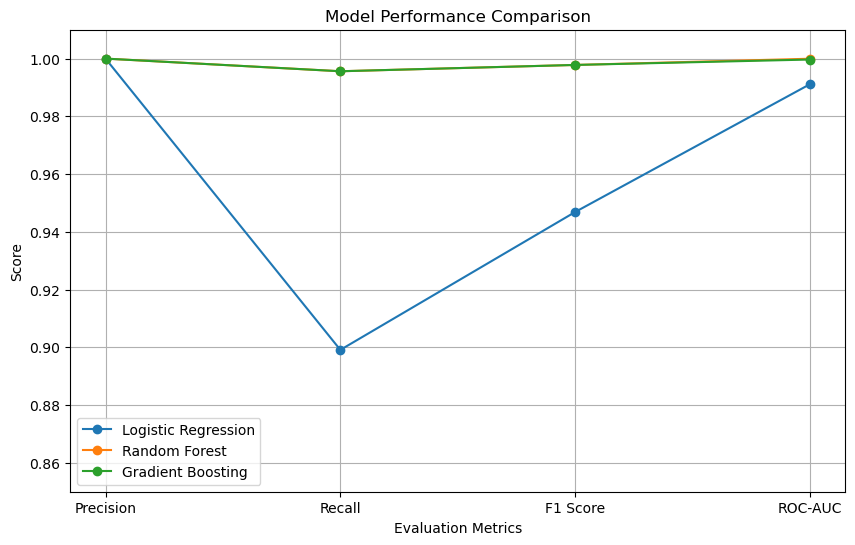

In [51]:
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC"]

x = range(len(metrics))

plt.figure(figsize=(10, 6))

for _, row in final_comparison.iterrows():
    plt.plot(
        x,
        row[metrics].to_numpy(dtype=float),
        marker="o",
        label=row["Model"]
    )

plt.xticks(x, metrics)
plt.ylim(0.85, 1.01)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [52]:
model_comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.00,0.90,0.95,0.99
1,Random Forest,1.00,1.00,1.00,1.00
2,Gradient Boosting,1.00,1.00,1.00,1.00
